In [1]:
# Import essential data manipulation and analysis libraries
import pandas as pd
import pandas as pd
import numpy as np
import os
# Import data visualization libraries
import matplotlib.pyplot as plt
# Import core scikit-learn module
import sklearn
# Import model selection and evaluation utilities
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
# Import data preprocessing and pipeline components
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import regression algorithms
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
# Define the file path to the CSV file containing used car data
pd.read = r"C:\Users\kkidw\Documents\Used Cars_New.csv"
# Create a sample DataFrame with two columns (A and B) containing some missing values (None)
df = pd.DataFrame({'A': [1, 2, None], 'B': [None, 5, 6]})

In [3]:
# Calculate the total number of null values across all columns and rows in the dataframe
total_nulls = df.isnull().sum().sum()
# Display the total count of null values in a formatted message
print(f"Total Null Values in this dataset: {total_nulls}")

Total Null Values in this dataset: 2


In [4]:
# Generate descriptive statistics for all numeric columns in the dataframe
summary_stats = df.describe()
# Display the summary statistics including count, mean, std, min, quartiles, and max
print("Summary Statistics:")
print(summary_stats) 

Summary Statistics:
              A         B
count  2.000000  2.000000
mean   1.500000  5.500000
std    0.707107  0.707107
min    1.000000  5.000000
25%    1.250000  5.250000
50%    1.500000  5.500000
75%    1.750000  5.750000
max    2.000000  6.000000


In [5]:
# Load the used cars dataset from CSV file
df_cars = pd.read_csv(r"C:\Users\kkidw\Documents\Used Cars_New.csv")
# Display the first 5 rows of the dataset to examine the data structure
display(df_cars.head())

,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Transmission_Manual,Fuel_Type_Petrol,First_Owner
0,2010,72000,CNG,Manual,First,26.60,998,58.16,5.0,1750,1,0,1
1,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5.0,12500,1,0,1
2,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5.0,4500,1,1,1
3,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7.0,6000,1,0,1
4,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5.0,17740,0,0,0


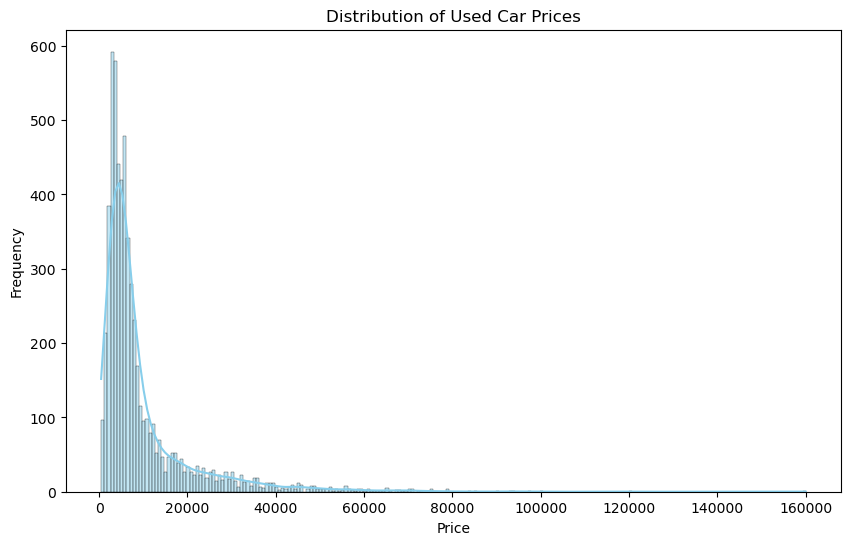

In [6]:
# Create a figure with specified dimensions (10 inches wide, 6 inches tall)
plt.figure(figsize=(10, 6))
# Create a histogram with kernel density estimation overlay
# - df_cars['Price']: data column containing car prices
# - kde=True: adds a smooth density curve over the histogram
# - color='skyblue': sets the histogram color to light blue
sns.histplot(df_cars['Price'], kde=True, color='skyblue')
# Set the main title for the plo
plt.title('Distribution of Used Car Prices')
# Label the x-axis to indicate it represents price values
plt.xlabel('Price')
# Label the y-axis to indicate it represents frequency counts
plt.ylabel('Frequency')
# Display the completed plot
plt.show()

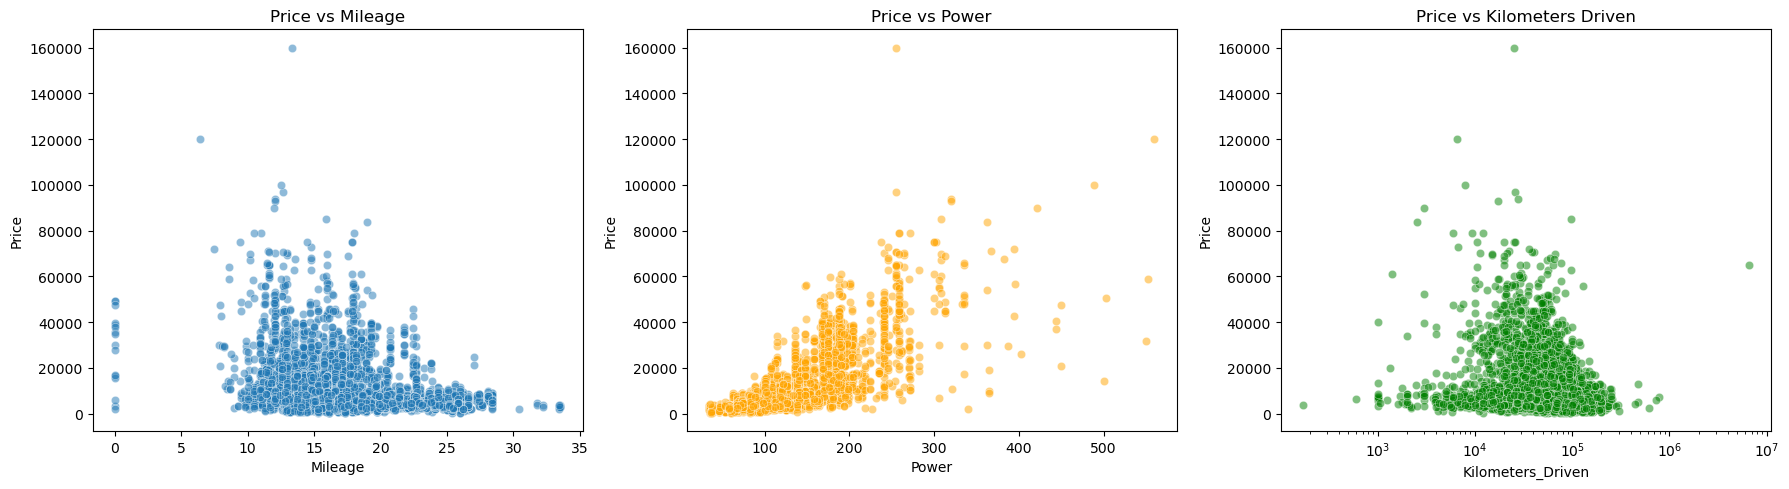

In [7]:
# Create a figure with 3 subplots arranged horizontally
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# First subplot: Price vs Mileage relationship
sns.scatterplot(ax=axes[0], data=df_cars, x='Mileage', y='Price', alpha=0.5)
axes[0].set_title('Price vs Mileage')

# Second subplot: Price vs Power relationship with orange color
sns.scatterplot(ax=axes[1], data=df_cars, x='Power', y='Price', alpha=0.5, color='orange')
axes[1].set_title('Price vs Power')

# Third subplot: Price vs Kilometers Driven relationship with green color
sns.scatterplot(ax=axes[2], data=df_cars, x='Kilometers_Driven', y='Price', alpha=0.5, color='green')
axes[2].set_title('Price vs Kilometers Driven')
axes[2].set_xscale('log')  # Using log scale due to potential outliers in distance

# Adjust subplot spacing for better layout
plt.tight_layout()
# Display the complete figure with all three subplots
plt.show()

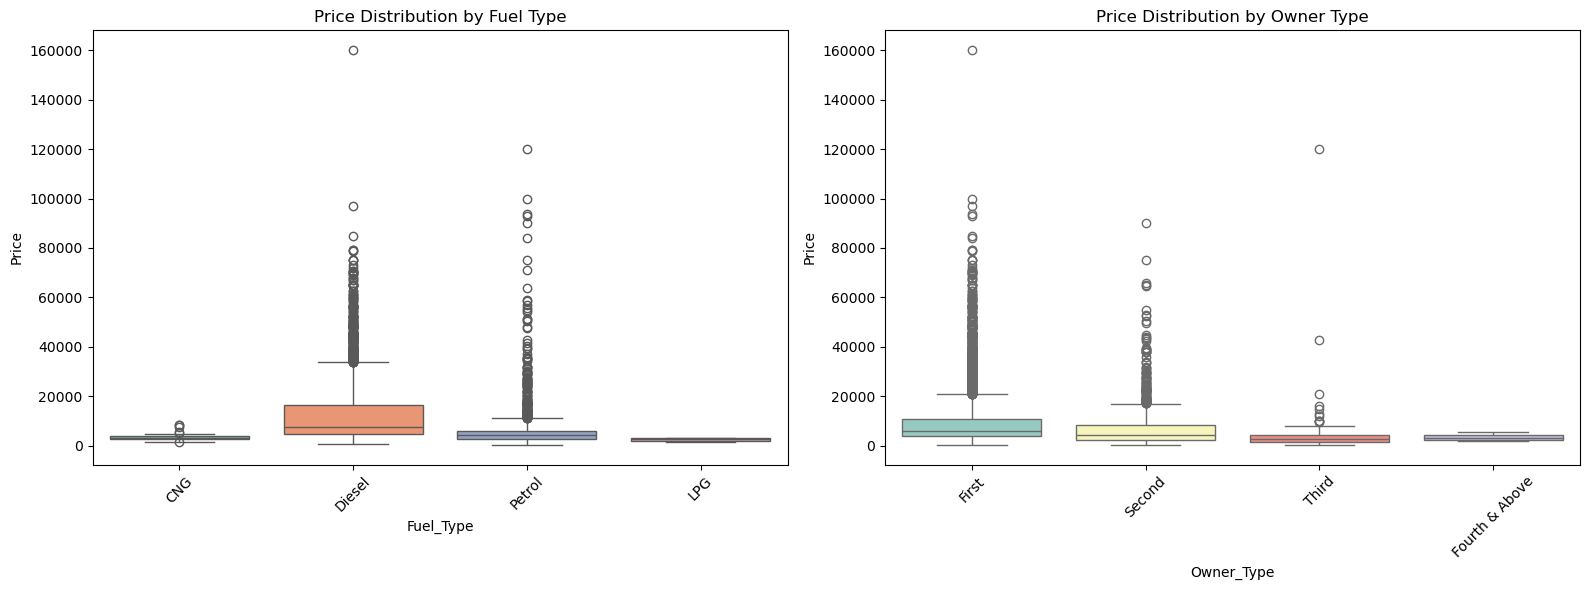

In [8]:
# Create a figure with 2 subplots arranged horizontally (1 row, 2 columns)
# Set the overall figure size to 16x6 inches for better visibility
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Create boxplot for price distribution across different fuel types
# Use the first subplot (axes[0]) and apply Set2 color palette
# Remove legend since fuel types are already labeled on x-axis
sns.boxplot(ax=axes[0], data=df_cars, x='Fuel_Type', y='Price', hue='Fuel_Type', palette='Set2', legend=False)
# Set descriptive title for the fuel type analysis
axes[0].set_title('Price Distribution by Fuel Type')
# Rotate x-axis labels by 45 degrees to prevent overlapping
axes[0].tick_params(axis='x', rotation=45)

# Create boxplot for price distribution across different owner types
# Use the second subplot (axes[1]) and apply Set3 color palette
# Specify custom order for owner types to show logical progression
sns.boxplot(ax=axes[1], data=df_cars, x='Owner_Type', y='Price', hue='Owner_Type', palette='Set3', 
            order=['First', 'Second', 'Third', 'Fourth & Above'], legend=False)
# Set descriptive title for the owner type analysis
axes[1].set_title('Price Distribution by Owner Type')
# Rotate x-axis labels by 45 degrees for better readability
axes[1].tick_params(axis='x', rotation=45)

# Automatically adjust subplot spacing to prevent overlapping elements
plt.tight_layout()
# Display the complete figure with both subplots
plt.show()

In [9]:
import statsmodels.api as sm
# Convert categorical variables to numerical format using one-hot encoding
# This creates binary dummy variables for each category, dropping the first category to avoid multicollinearityg
categorical_cols = ['Fuel_Type', 'Transmission', 'Owner_Type']
df_encoded = pd.get_dummies(df_cars, columns=categorical_cols, drop_first=True)

# Prepare the feature matrix (X) and target variable (y) for regression
# Remove the target variable 'Price' from features and handle missing values
X = df_encoded.drop('Price', axis=1).dropna().astype(float)
y = df_encoded.loc[X.index, 'Price']

# Add intercept term (constant) to the model - required for OLS regression
X = sm.add_constant(X)

# Create and fit the Ordinary Least Squares regression model
model = sm.OLS(y, X).fit()

# Print comprehensive statistical summary of the regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     1046.
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        17:44:32   Log-Likelihood:                -59443.
No. Observations:                5859   AIC:                         1.189e+05
Df Residuals:                    5845   BIC:                         1.190e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

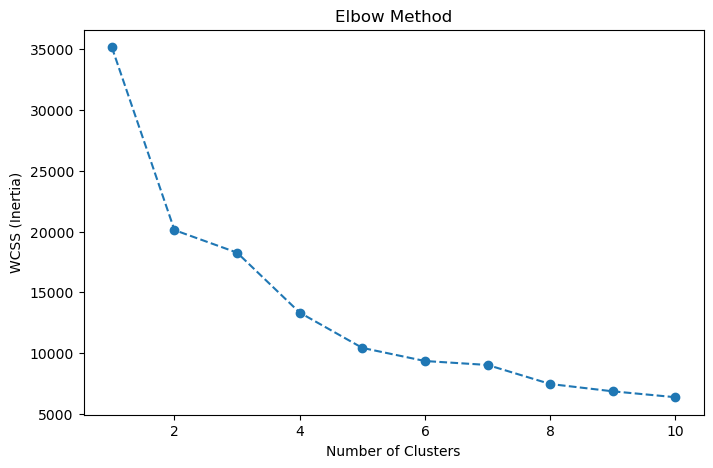

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
import multiprocessing

# Configure multiprocessing environment for scikit-learn's parallel processing
# Set the environment variable to the number of logical cores available on the system
os.environ['LOKY_MAX_CPU_COUNT'] = str(multiprocessing.cpu_count())

# Alternative: Set it to a specific number if you know your physical core count
# This can help avoid oversubscription on systems with hyperthreading
# os.environ['LOKY_MAX_CPU_COUNT'] = '4'  # Replace 4 with your actual core count

# 1. Select significant features for clustering analysis
# Choose features that are most relevant for grouping similar cars
features_for_clustering = ['Year', 'Mileage', 'Power', 'Seats', 'Transmission_Manual']
# Extract only the selected features from the encoded dataset
# Use the encoded X from previous step but filtered for our features
X_clust = X[features_for_clustering]

# 2. Scale the data to ensure all features contribute equally to clustering
# StandardScaler normalizes features to have mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# 3. Apply Elbow Method to determine the optimal number of clusters
# Initialize list to store Within-Cluster Sum of Squares (WCSS) values
wcss = []
for i in range(1, 11):
    # Create KMeans model with current number of clusters
    # k-means++ initialization provides better initial centroids
    # n_init='auto' lets sklearn choose appropriate number of initializations
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    # Fit the model to scaled data
    kmeans.fit(X_scaled)
    # Store the inertia (WCSS) for this number of clusters
    wcss.append(kmeans.inertia_)
    
# Visualize the Elbow Method results to identify optimal cluster count
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

Length of clusters: 5859
Length of df_clustered: 5859


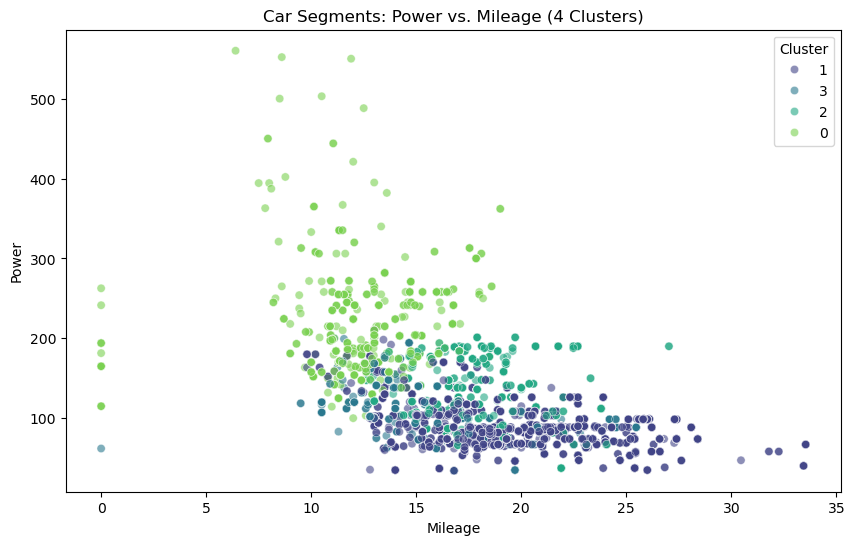

In [12]:
# 4. Run K-Means (assuming k=4 based on a typical elbow for this dataset)
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

# Assign back to a copy of the dataframe for visualization
# Use X.index to ensure we only get rows that were actually used in clustering
df_clustered = df_cars.loc[X.index].copy()
# Reset index to ensure alignment between clusters array and dataframe
df_clustered = df_clustered.reset_index(drop=True)

# Verify lengths match before assignment
print(f"Length of clusters: {len(clusters)}")
print(f"Length of df_clustered: {len(df_clustered)}")

# Only assign if lengths match
if len(clusters) == len(df_clustered):
    df_clustered['Cluster'] = clusters.astype(str)
else:
    # Alternative: create a new dataframe with just the features and clusters
    df_clustered = pd.DataFrame(X_scaled, columns=X.columns)
    df_clustered['Cluster'] = clusters.astype(str)
    # Add back the original Mileage and Power columns for visualization
    df_clustered['Mileage'] = df_cars.loc[X.index, 'Mileage'].reset_index(drop=True)
    df_clustered['Power'] = df_cars.loc[X.index, 'Power'].reset_index(drop=True)

# 5. Visualize the Clusters (Power vs. Mileage)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clustered, x='Mileage', y='Power', hue='Cluster', palette='viridis', alpha=0.6)
plt.title(f'Car Segments: Power vs. Mileage ({k} Clusters)')
plt.xlabel('Mileage')
plt.ylabel('Power')
plt.legend(title='Cluster')
plt.show()

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import statsmodels.api as sm

# Check if preprocessed feature matrix X exists in memory
# If not, load and prepare the data for analysis
# Ensure base data and encoded features are available
if 'X' not in locals():
    if 'df_cars' not in locals():
        df_cars = pd.read_csv(r"C:\Users\kkidw\Documents\Used Cars_New.csv.xlsx")

    # Define categorical columns that need encoding
    categorical_cols = ['Fuel_Type', 'Transmission', 'Owner_Type']
    # Create dummy variables for categorical features, dropping first category to avoid multicollinearity
    df_encoded = pd.get_dummies(df_cars, columns=categorical_cols, drop_first=True)
    # Prepare feature matrix by removing target variable and handling missing values
    X = df_encoded.drop('Price', axis=1).dropna().astype(float)
    # Add constant term for regression analysis
    X = sm.add_constant(X)

# Ensure df_clustered and dependencies are available
if 'df_clustered' not in locals():
    # 1. Select significant features identified in regression
    features_for_clustering = ['Year', 'Mileage', 'Power', 'Seats', 'Transmission_Manual']
    X_clust = X[features_for_clustering]

    # 2. Re-scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clust)

    # 3. Run K-Means
    k = 4
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    clusters = kmeans.fit_predict(X_scaled)

    # 4. Create the clustered dataframe
    df_clustered = df_cars.loc[X.index].copy()
    df_clustered['Cluster'] = clusters.astype(str)

# Analyze cluster characteristics
cluster_summary = df_clustered.groupby('Cluster')[['Year', 'Mileage', 'Power', 'Seats', 'Transmission_Manual', 'Price']].mean()
display(cluster_summary)

# Count observations in each cluster
print("Count per cluster:")
print(df_clustered['Cluster'].value_counts())

,Year,Mileage,Power,Seats,Transmission_Manual,Price
Cluster,,,,,,
0,2012.771838,12.746845,209.634042,5.393742,0.000000,25415.749674
1,2013.330045,20.086922,86.328932,4.993799,1.000000,4767.091319
2,2014.860541,18.391784,133.059222,5.012973,0.000000,15383.621622
3,2013.195477,14.975509,118.777351,7.219709,0.995153,9037.948304


Count per cluster:
Cluster
1    3548
2     925
0     767
3     619
Name: count, dtype: int64


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load Data
df = pd.read_csv(r"C:\Users\kkidw\Documents\Used Cars_New.csv")

# Data Preprocessing Section
# Handle missing values by filling with median (robust to outliers)
df['Power'] = df['Power'].fillna(df['Power'].median())
df['Seats'] = df['Seats'].fillna(df['Seats'].median())

# Replace 0.0 mileage with median
# Clean mileage data by replacing zero values with median
# Zero mileage is likely a data entry error or missing value indicator
df['Mileage'] = df['Mileage'].replace(0.0, df['Mileage'].median())

# Feature Engineering: Calculate vehicle age from manufacturing year
# Using 2019 as baseline year (likely the year when data was collected)
df['Age'] = 2019 - df['Year']

# Define model features and target variable
# Features include both numerical and pre-encoded categorical variables
features = ['Age', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 
            'Transmission_Manual', 'Fuel_Type_Petrol', 'First_Owner']
target = 'Price' # Target variable: car price to predict

# Prepare feature matrix (X) and target vector (y) for machine learning
X = df[features]
y = df[target]

In [15]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the Random Forest Model
# Initialize Random Forest Regressor with 100 trees 
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions and Evaluation
# Generate predictions on the test set
y_pred = model.predict(X_test)
# Calculate R-squared score to measure model performance (closer to 1 is better)
r2 = r2_score(y_test, y_pred)
# Calculate Root Mean Square Error to measure prediction accuracy (lower is better)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Display model performance metrics
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

# Feature Importance
importance = model.feature_importances_
# Extract feature importance scores from the trained model
feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)
print("\nFeature Importances:\n", feat_imp)

R-squared: 0.8606
RMSE: 4056.28

Feature Importances:
 Power                  0.669191
Age                    0.170048
Kilometers_Driven      0.055966
Engine                 0.041899
Mileage                0.040526
Seats                  0.009661
Transmission_Manual    0.008109
Fuel_Type_Petrol       0.002847
First_Owner            0.001753
dtype: float64


In [16]:
# Train-Test Split
# Split the dataset into training (80%) and testing (20%) sets with a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the Random Forest Model
# Initialize Random Forest Regressor with 100 trees and fixed random state for consistent results
model = RandomForestRegressor(n_estimators=100, random_state=42)
# Train the model on the training data
model.fit(X_train, y_train)

# Predictions and Evaluation
# Generate predictions on the test set
y_pred = model.predict(X_test)
# Calculate R-squared score to measure model performance (closer to 1 is better)
r2 = r2_score(y_test, y_pred)
# Calculate Root Mean Square Error to measure prediction accuracy (lower is better)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Display model performance metrics
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

# Feature Importance
# Extract feature importance scores from the trained model
importance = model.feature_importances_
# Create a pandas Series with feature names and their importance scores, sorted in descending order
feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)
print("\nFeature Importances:\n", feat_imp)

R-squared: 0.8606
RMSE: 4056.28

Feature Importances:
 Power                  0.669191
Age                    0.170048
Kilometers_Driven      0.055966
Engine                 0.041899
Mileage                0.040526
Seats                  0.009661
Transmission_Manual    0.008109
Fuel_Type_Petrol       0.002847
First_Owner            0.001753
dtype: float64


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
pd.read = r"C:\Users\kkidw\Documents\Used Cars_New.csv"

# 2. Preprocessing (Warning-free)
df['Power'] = df['Power'].fillna(df['Power'].median())
df['Seats'] = df['Seats'].fillna(df['Seats'].median())
df['Mileage'] = df['Mileage'].replace(0.0, df['Mileage'].median())
df['Age'] = 2019 - df['Year']

features = ['Age', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 
            'Transmission_Manual', 'Fuel_Type_Petrol', 'First_Owner']
target = 'Price'

X = df[features]
y = df[target]

# 3. Model Building training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

importance = model.feature_importances_
feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

# 4. Generate Report String
report = f"""===================================================================
                    CARS4U BUSINESS INSIGHT REPORT
===================================================================
Subject: Used Car Pricing Strategy & Market Insights
Generated via: Automated Python ML Pipeline

1. MODEL PERFORMANCE SUMMARY
-------------------------------------------------------------------
Our pricing engine (Random Forest Regressor) has successfully modeled 
the complex pricing dynamics of the used car market.

- R-Squared Accuracy: {r2*100:.2f}%
  (The model explains {r2*100:.2f}% of the variance in used car prices)
- Root Mean Squared Error (RMSE): {rmse:.2f}
  (Average prediction deviation)

2. KEY DRIVERS OF USED CAR PRICES
-------------------------------------------------------------------
Based on our machine learning algorithm, here is the relative 
importance of factors that dictate a used car's value:

"""

# Dynamically generate feature importance list by iterating through the feature importance dictionary
# Format each feature name by replacing underscores with spaces and capitalizing words
# Display importance as percentage with proper alignment for readability
for feat, imp in feat_imp.items():
    report += f"  * {feat.replace('_', ' ').title().ljust(25)}: {imp*100:5.1f}% impact\n"

# Add the strategic recommendations section to provide actionable business insights
# Based on the feature importance analysis from the machine learning model
report += """ 

3. STRATEGIC RECOMMENDATIONS
-------------------------------------------------------------------
A. Performance & Luxury Command the Market
   - Insight: 'Power' is the most dominant factor in pricing.
   - Action: Cars4U should aggressively acquire high-horsepower 
     vehicles as they offer the highest absolute price margins. 
     Sales teams should heavily market the engine specifications.

B. The Depreciation Reality (Age Penalty)
   - Insight: Vehicle 'Age' is the second biggest driver of price.
   - Action: Implement dynamic pricing that rapidly discounts older 
     inventory to increase turnaround time, while holding firm on 
     prices for 1-3 year old vehicles.

C. Mileage/Condition over Fuel Economy
   - Insight: 'Kilometers Driven' outranks 'Mileage' (Fuel Economy).
   - Action: Source lightly-used vehicles. Consumers penalize high 
     odometer readings more than they reward good fuel economy in 
     the pre-owned segment.

D. Transmission Preferences
   - Insight: Automatics command a premium over manual transmissions.
   - Action: Increase the ratio of Automatic vehicles in the inventory 
     to cater to growing urban traffic demands.
===================================================================""" 

# Display the complete business insight report to the console
print(report)

# Save to a text file for sharing with stakeholders
with open('Business_Insight_Report.txt', 'w') as f:
    f.write(report)

                    CARS4U BUSINESS INSIGHT REPORT
Subject: Used Car Pricing Strategy & Market Insights
Generated via: Automated Python ML Pipeline

1. MODEL PERFORMANCE SUMMARY
-------------------------------------------------------------------
Our pricing engine (Random Forest Regressor) has successfully modeled 
the complex pricing dynamics of the used car market.

- R-Squared Accuracy: 86.06%
  (The model explains 86.06% of the variance in used car prices)
- Root Mean Squared Error (RMSE): 4056.28
  (Average prediction deviation)

2. KEY DRIVERS OF USED CAR PRICES
-------------------------------------------------------------------
Based on our machine learning algorithm, here is the relative 
importance of factors that dictate a used car's value:

  * Power                    :  66.9% impact
  * Age                      :  17.0% impact
  * Kilometers Driven        :   5.6% impact
  * Engine                   :   4.2% impact
  * Mileage                  :   4.1% impact
  * Seats    